#  LSTM? — It's purpose-built for sequence data like text. It captures word order and context, making it ideal for sentiment classification. A Bidirectional LSTM reads text in both directions for even better understanding

In [1]:
# importing models 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================================= EDA =================================================

In [3]:
dataset  = pd.read_csv('../datasets/amazon.csv')
dataset.head()
dataset.info()
dataset.shape
dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   str    
 2   overall               4915 non-null   int64  
 3   reviewText            4914 non-null   str    
 4   reviewTime            4915 non-null   str    
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(2), int64(7), str(3)
memory usage: 460.9 KB


,Unnamed: 0,overall,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
count,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000,4915.000000
mean,2457.000000,4.587589,437.367040,1.311089,0.210376,1.521465,1.100712,0.075468,0.020053
std,1418.982617,0.996845,209.439871,41.619161,4.023296,44.123095,39.367949,0.256062,0.077187
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-130.000000,0.000000,0.000000
25%,1228.500000,5.000000,281.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2457.000000,5.000000,431.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3685.500000,5.000000,601.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4914.000000,5.000000,1064.000000,1952.000000,183.000000,2020.000000,1884.000000,1.000000,0.957544


In [4]:
# printing all the columns in the dataset
print(dataset.columns)

Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='str')


In [5]:
# removing unwanted columns 
dataset  = dataset.drop(["Unnamed: 0","reviewerName","reviewTime"],axis=1)

In [6]:
dataset.columns

Index(['overall', 'reviewText', 'day_diff', 'helpful_yes', 'helpful_no',
       'total_vote', 'score_pos_neg_diff', 'score_average_rating',
       'wilson_lower_bound'],
      dtype='str')

In [7]:
# checking for null values 
dataset.isnull().sum()

overall                 0
reviewText              1
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [8]:
# since reviewText has 1 null value, we will drop that row
dataset = dataset.dropna(subset=["reviewText"])

In [9]:
dataset.isnull().sum()

overall                 0
reviewText              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

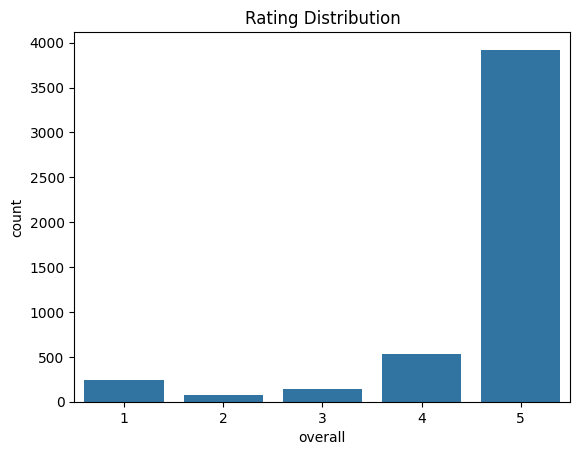

In [10]:
# examining the rating distribution 
sns.countplot(x="overall",data=dataset)
plt.title("Rating Distribution")
plt.show()

In [11]:
# so i got to know dataset is imbalances and most of reviews are 5 star reviews 
# so the dataset is biased towards the positive sentiment 
# solition : 
# 1. class weighting
# 2. oversampling the minority class
# 3. under-sampling the majority class
# 4. Imblean-learn library
#5. smote 
# 6. ensemble learning 



In [12]:
# sentiment distribution labeling 

def map_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"
    
dataset["sentiment"] = dataset["overall"].apply(map_sentiment)
print(dataset["sentiment"].value_counts())


sentiment
positive    4448
negative     324
neutral      142
Name: count, dtype: int64


C:\Users\Anirban\AppData\Local\Temp\ipykernel_4796\476116905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


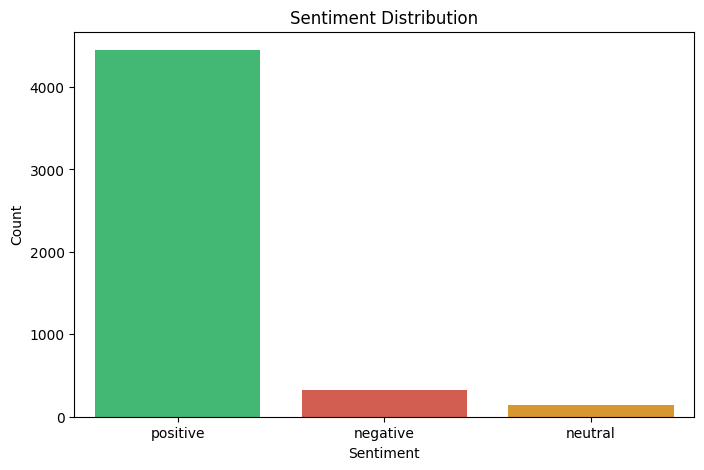

In [13]:
# since the dataset is imbalanced, we will use class weighting to handle the imbalance
# we are going to see the distribution of sentiments in the dataset
plt.figure(figsize=(8, 5))
sentiment_counts = dataset["sentiment"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [14]:
# Review Length Analysis
dataset["review_length"] = dataset["reviewText"].apply(lambda x: len(x.split()))
print("Review Length Statistics:")
print(dataset.groupby("sentiment")["review_length"].describe().round(2))

Review Length Statistics:
            count    mean     std  min   25%   50%    75%     max
sentiment                                                        
negative    324.0  106.48  133.85  4.0  43.0  78.0  120.0  1554.0
neutral     142.0   73.25   71.26  7.0  30.0  50.0   94.0   580.0
positive   4448.0   45.64   46.15  1.0  23.0  31.0   50.0  1037.0


C:\Users\Anirban\AppData\Local\Temp\ipykernel_4796\2581496646.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x="sentiment", y="review_length",


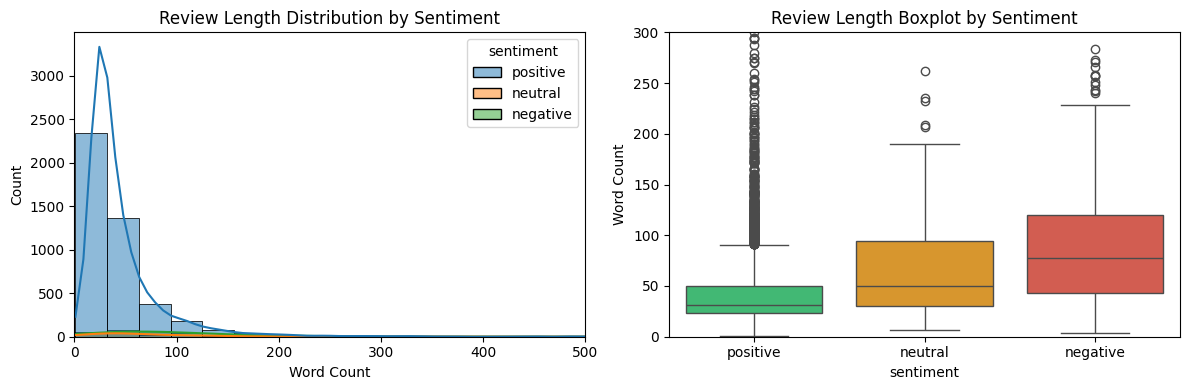

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=dataset, x="review_length", hue="sentiment", bins=50, kde=True)
plt.xlim(0, 500)
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Word Count")

plt.subplot(1, 2, 2)
sns.boxplot(data=dataset, x="sentiment", y="review_length",
order=["positive", "neutral", "negative"],
palette=["#2ecc71", "#f39c12", "#e74c3c"])
plt.ylim(0, 300)
plt.title("Review Length Boxplot by Sentiment")
plt.ylabel("Word Count")

plt.tight_layout()
plt.show()

In [16]:
# what i figured out most ppls write short reviews and length mostly btn 0-60 words 
# 2nd plot is for mean and dots are outliers 
# distribution is skewed towards short reviews and there are some outliers with very long reviews


In [17]:
### Most common words in each sentiment category

In [18]:
from sklearn.feature_extraction.text import CountVectorizer as CV
vectorizer = CV(stop_words="english",max_features=35)
x = vectorizer.fit_transform(dataset["reviewText"])
print(vectorizer.get_feature_names_out())

['10' 'adapter' 'bought' 'camera' 'card' 'cards' 'class' 'fast' 'galaxy'
 'gb' 'good' 'got' 'great' 'just' 'like' 'memory' 'micro' 'music' 'note'
 'phone' 'price' 'problems' 'product' 'samsung' 'sandisk' 'sd' 'space'
 'speed' 'storage' 'tablet' 'use' 'using' 've' 'work' 'works']


In [19]:
positive_reviews = dataset[dataset["sentiment"]=="positive"]["reviewText"]
negative_reviews = dataset[dataset["sentiment"]=="negative"]["reviewText"]

In [20]:
vectorizer = CV(stop_words="english", max_features=20)

pos_words = vectorizer.fit_transform(positive_reviews)
print("Positive words:", vectorizer.get_feature_names_out())

neg_words = vectorizer.fit_transform(negative_reviews)
print("Negative words:", vectorizer.get_feature_names_out())

Positive words: ['bought' 'card' 'cards' 'fast' 'galaxy' 'good' 'great' 'just' 'memory'
 'music' 'phone' 'price' 'samsung' 'sandisk' 'sd' 'speed' 'storage'
 'tablet' 'use' 'works']
Negative words: ['10' 'amazon' 'bought' 'card' 'cards' 'class' 'data' 'format' 'galaxy'
 'got' 'just' 'memory' 'months' 'phone' 'problem' 'read' 'samsung'
 'sandisk' 'sd' 'tried']


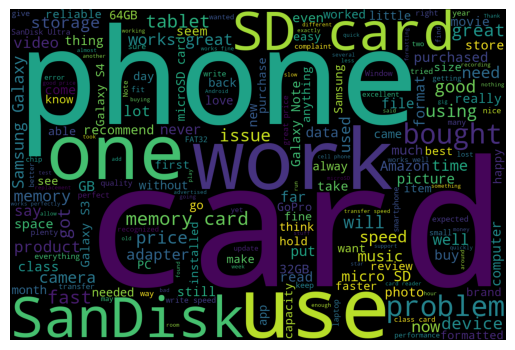

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(dataset["reviewText"])

wordcloud = WordCloud(width=1200, height=800).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

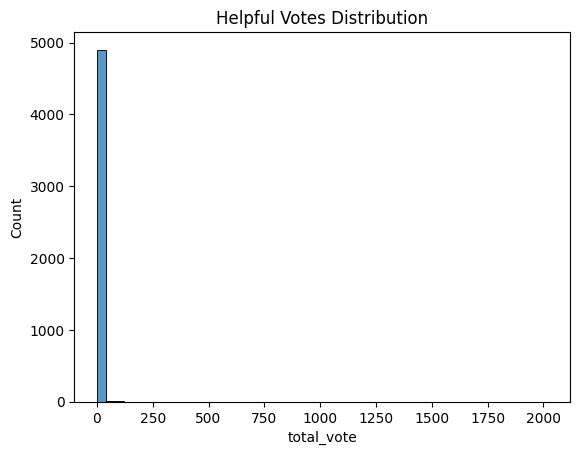

In [22]:
sns.histplot(data=dataset, x="total_vote", bins=50)
plt.title("Helpful Votes Distribution")
plt.show()

In [23]:
# text preprocessing (cleaning the text data)
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

dataset["clean_text"] = dataset["reviewText"].apply(clean_text)

In [24]:
vectorizer = CV(stop_words="english", ngram_range=(2,2), max_features=20)

bigrams = vectorizer.fit_transform(dataset["clean_text"])
print(vectorizer.get_feature_names_out())

['card phone' 'card reader' 'card works' 'galaxy note' 'galaxy tab'
 'gb card' 'good price' 'gopro hero' 'great price' 'memory card'
 'memory cards' 'micro sd' 'microsd card' 'samsung galaxy' 'sandisk ultra'
 'sd card' 'sd cards' 'works fine' 'works great' 'works perfectly']


# ================================================= MODEL PREPARATION =================================================
## Steps: Label Encode → Tokenize → Pad Sequences → Train/Test Split

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ── Parameters ──────────────────────────────────────────────────────────────
MAX_WORDS   = 20000   # larger vocab → fewer OOV tokens
MAX_LEN     = 200     # 200 words covers ~95% of reviews (was 150)
EMBED_DIM   = 128     # richer token representations (was 64)
EPOCHS      = 20      # give minority classes more gradient steps (was 5)
BATCH_SIZE  = 64      # smaller batch = noisier gradients = better minority learning (was 128)

# ── 1. Label Encoding ────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(dataset["sentiment"])   # negative=0, neutral=1, positive=2
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Full class distribution:", dict(zip(le.classes_, np.bincount(y))))

# ── 2. Tokenize ──────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(dataset["clean_text"])
sequences = tokenizer.texts_to_sequences(dataset["clean_text"])

# ── 3. Pad Sequences ─────────────────────────────────────────────────────────
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ── 4. Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
counts = np.bincount(y_train)
print(f"Train distribution — negative: {counts[0]}, neutral: {counts[1]}, positive: {counts[2]}")
print(f"Imbalance ratio (positive/negative): {counts[2]/counts[0]:.1f}x")

Class mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Full class distribution: {'negative': np.int64(324), 'neutral': np.int64(142), 'positive': np.int64(4448)}
X shape: (4914, 200), y shape: (4914,)
Train: (3931, 200), Test: (983, 200)
Train distribution — negative: 259, neutral: 114, positive: 3558
Imbalance ratio (positive/negative): 13.7x


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense,
                                      Dropout, SpatialDropout1D, GlobalMaxPooling1D,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

NUM_CLASSES = 3

def build_bilstm():
    """
    Upgraded BiLSTM shared across Experiments 1–6.
    Key upgrades vs v1:
      • SpatialDropout1D: drops entire embedding dimensions per token → better text regularisation
      • Larger BiLSTM units (128→64) for richer context
      • GlobalMaxPooling1D: captures the peak sentiment signal regardless of position
      • BatchNormalization + deeper Dense head for cleaner gradient flow
      • Lower learning rate (5e-4) for more stable minority-class learning
    """
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, return_sequences=True)),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def evaluate_model(model, X_test, y_test, label="Model"):
    """Print classification report + confusion matrix and return macro-F1."""
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix — {label}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

    return f1_score(y_test, y_pred, average="macro")

# Patience=4: give the model more time before giving up on a plateau
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
print("Model builder ready. Architecture summary:")
build_bilstm().summary()

Model builder ready. Architecture summary:


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# ── EXPERIMENT 1: Baseline (No Imbalance Handling) ─────────────────
> Train on raw imbalanced data. Expect high accuracy but poor recall on minority classes.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.6384 - loss: 0.7975 - val_accuracy: 0.8985 - val_loss: 0.7193
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8807 - loss: 0.4939 - val_accuracy: 0.8985 - val_loss: 0.6667
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8945 - loss: 0.4601 - val_accuracy: 0.8985 - val_loss: 0.5919
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9005 - loss: 0.3994 - val_accuracy: 0.8985 - val_loss: 0.4538
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9033 - loss: 0.3502 - val_accuracy: 0.8985 - val_loss: 0.3622
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9183 - loss: 0.2787 - val_accuracy: 0.9036 - val_loss: 0.3149
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9364 - loss: 0.2112 - val_accuracy: 0.9213 - val_loss: 0.2727
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9514 - loss: 0.1754 - val_accuracy: 0.9188 - val_loss

d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


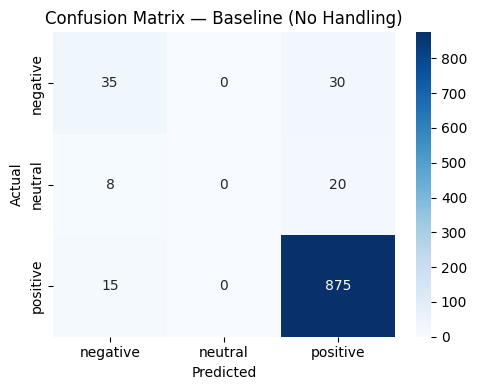

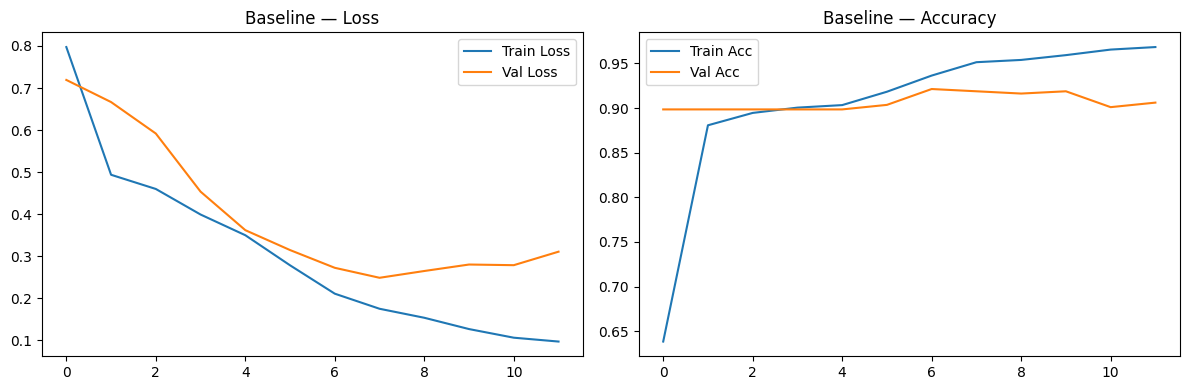

In [27]:
model_baseline = build_bilstm()
model_baseline.summary()

history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

f1_baseline = evaluate_model(model_baseline, X_test, y_test, label="Baseline (No Handling)")

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_baseline.history["accuracy"], label="Train Acc")
plt.plot(history_baseline.history["val_accuracy"], label="Val Acc")
plt.title("Baseline — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── EXPERIMENT 2: Class Weights (Amplified) ────────────────────────
> Standard balanced weights penalise the model for minority mistakes. Here we **amplify** them with a power of 1.3 — pushing extra gradient signal toward neutral and negative without destabilising training. No data modification needed.

Balanced weights:   {'negative': np.float64(5.059), 'neutral': np.float64(11.494), 'positive': np.float64(0.368)}
Amplified weights:  {'negative': np.float64(0.762), 'neutral': np.float64(2.213), 'positive': np.float64(0.025)}


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 883ms/step - accuracy: 0.3523 - loss: 0.1518 - val_accuracy: 0.0482 - val_loss: 1.1663
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 804ms/step - accuracy: 0.3138 - loss: 0.1378 - val_accuracy: 0.0533 - val_loss: 1.2379
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.3681 - loss: 0.1284 - val_accuracy: 0.0381 - val_loss: 1.1838
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.4238 - loss: 0.1219 - val_accuracy: 0.0888 - val_loss: 1.1717

  Class Weights (Amplified)
              precision    recall  f1-score   support

    negative       0.62      0.08      0.14        65
     neutral       0.03      1.00      0.06        28
    positive       0.00      0.00      0.00       890

    accuracy                           0.03       983
   macro avg       0.22      0.36      0.06       983
weighted avg       0.04      0.03      0.01       983



d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


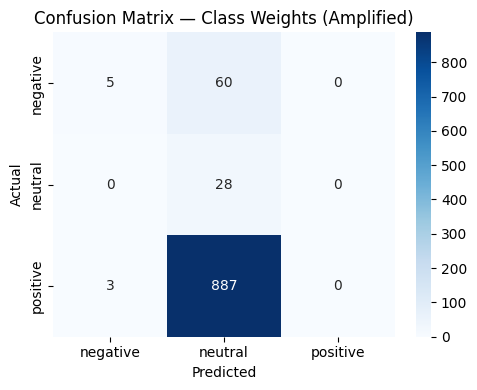

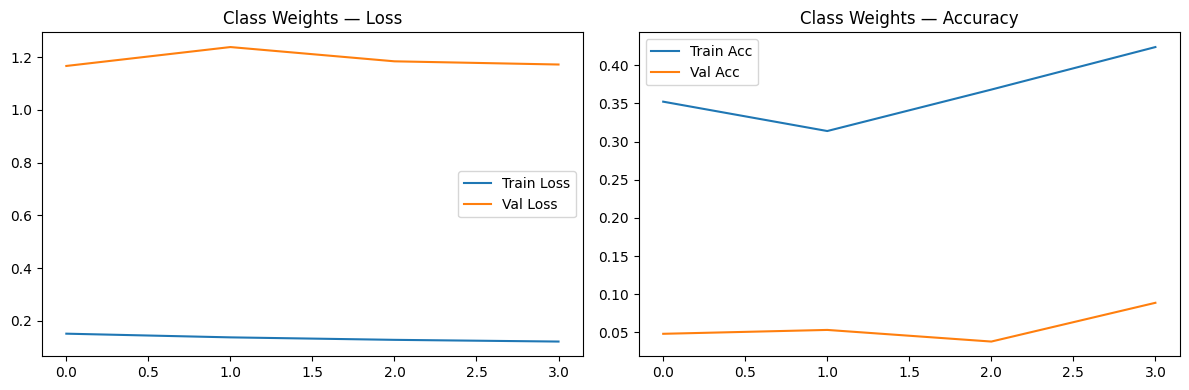

In [28]:
from sklearn.utils.class_weight import compute_class_weight

# ── Amplified class weights ───────────────────────────────────────────────────
# Step 1: standard balanced weights
cw_balanced = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
# Step 2: raise to power 1.3 — amplifies the minority signal without extreme instability
cw_amplified = cw_balanced ** 1.3
# Step 3: normalise so the mean weight = 1 (keeps loss magnitude scale-consistent)
cw_amplified = cw_amplified / cw_amplified.mean()
class_weights_dict = dict(enumerate(cw_amplified))
print("Balanced weights:  ", {le.classes_[k]: round(v, 3) for k, v in enumerate(cw_balanced)})
print("Amplified weights: ", {le.classes_[k]: round(v, 3) for k, v in class_weights_dict.items()})

model_cw = build_bilstm()

history_cw = model_cw.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

f1_cw = evaluate_model(model_cw, X_test, y_test, label="Class Weights (Amplified)")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_cw.history["loss"], label="Train Loss")
plt.plot(history_cw.history["val_loss"], label="Val Loss")
plt.title("Class Weights — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cw.history["accuracy"], label="Train Acc")
plt.plot(history_cw.history["val_accuracy"], label="Val Acc")
plt.title("Class Weights — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── EXPERIMENT 3: Random Oversampling (imblearn) ───────────────────
> Duplicate random samples from the minority classes until all classes are balanced. Works directly on padded sequences — no text-level augmentation needed.

After oversampling: [3558 3558 3558]
Epoch 1/20


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


151/151 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.6298 - loss: 0.7713 - val_accuracy: 0.2603 - val_loss: 1.1227
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9665 - loss: 0.1210 - val_accuracy: 0.9803 - val_loss: 0.3421
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9900 - loss: 0.0373 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9950 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 1.2068e-04
Epoch 5/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9955 - loss: 0.0198 - val_accuracy: 1.0000 - val_loss: 3.7404e-04
Epoch 6/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 1.9382e-04
Epoch 7/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9944 - loss: 0.0203 - val_accuracy: 0.9916 - val_loss: 0.0177
Epoch 8/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9931 - loss: 0.0253 - val_acc

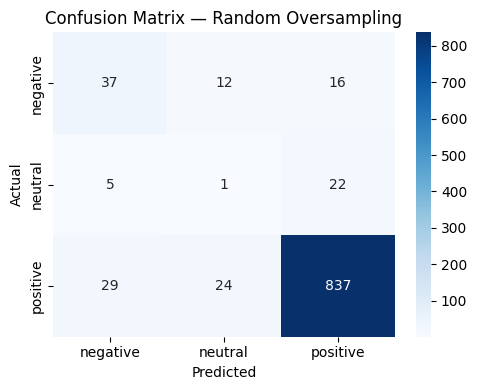

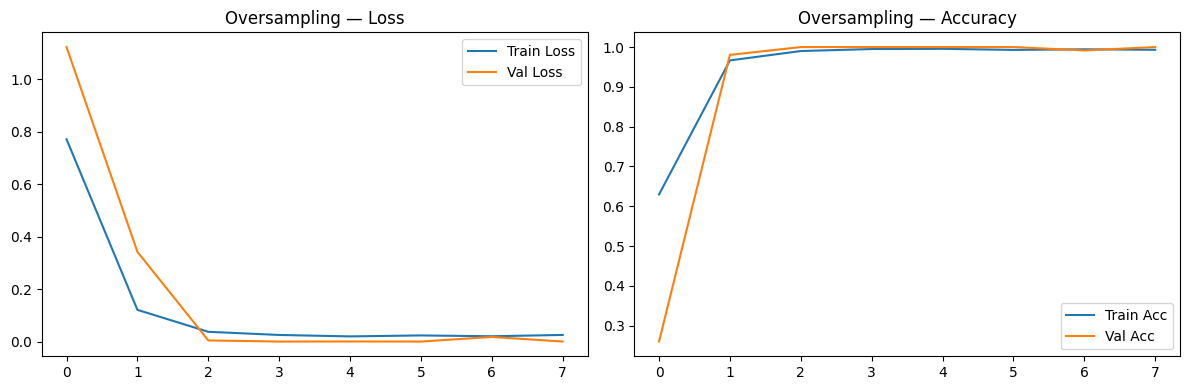

In [29]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print("After oversampling:", np.bincount(y_train_ros))

model_ros = build_bilstm()

history_ros = model_ros.fit(
    X_train_ros, y_train_ros,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

f1_ros = evaluate_model(model_ros, X_test, y_test, label="Random Oversampling")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_ros.history["loss"], label="Train Loss")
plt.plot(history_ros.history["val_loss"], label="Val Loss")
plt.title("Oversampling — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ros.history["accuracy"], label="Train Acc")
plt.plot(history_ros.history["val_accuracy"], label="Val Acc")
plt.title("Oversampling — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── EXPERIMENT 4: Random Undersampling ────────────────────────────
> Reduce the majority class (positive) to match the minority.
> ⚠️ **Previous problem**: default strategy balanced **all classes to the smallest**, leaving a tiny training set — too few samples for the BiLSTM to generalise.
> **Fix applied**: `sampling_strategy='not majority'` only shrinks the majority class down to match the **second-largest** class. Neutral and negative are untouched, so far more training data is preserved.

After undersampling: [ 114  114 3558]
Total training samples: 3786  (was 3931)
Epoch 1/20


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7981 - loss: 0.6161 - val_accuracy: 1.0000 - val_loss: 0.6369
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9137 - loss: 0.4097 - val_accuracy: 1.0000 - val_loss: 0.4450
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9216 - loss: 0.3748 - val_accuracy: 1.0000 - val_loss: 0.3855
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9260 - loss: 0.3290 - val_accuracy: 1.0000 - val_loss: 0.1604

  Random Undersampling (fixed)
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        65
     neutral       0.00      0.00      0.00        28
    positive       0.91      1.00      0.95       890

    accuracy                           0.91       983
   macro avg       0.30      0.33      0.32       983
weighted avg       0.82      0.91      0.86       983



d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


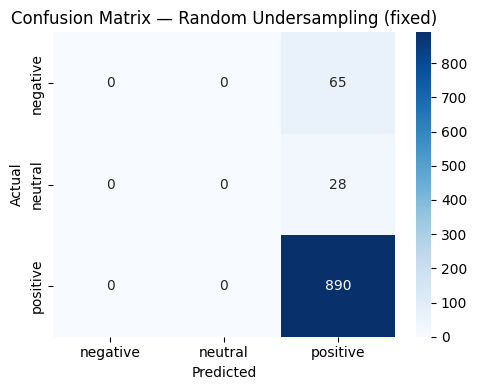

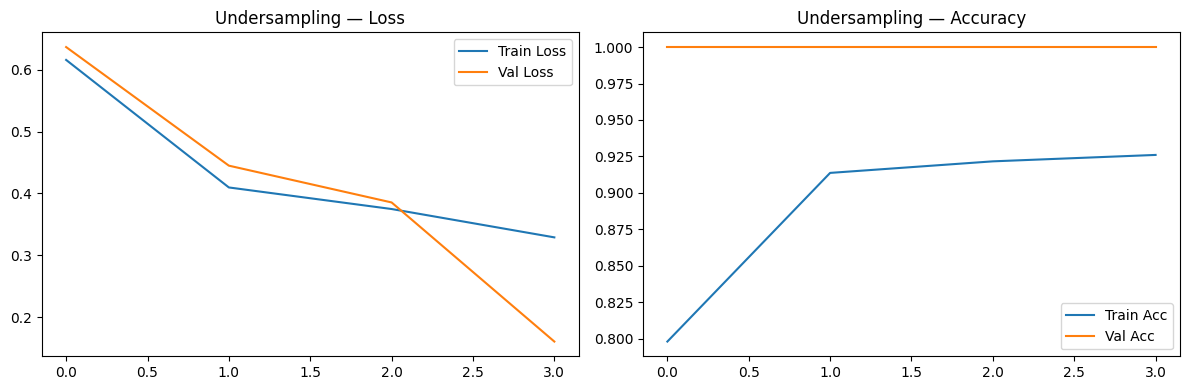

In [30]:
from imblearn.under_sampling import RandomUnderSampler

# 'not majority' → only shrinks the largest class down to the 2nd largest count
# preserves all minority class samples — much less data loss than full balance
rus = RandomUnderSampler(random_state=42, sampling_strategy='not majority')
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print("After undersampling:", np.bincount(y_train_rus))
print(f"Total training samples: {len(y_train_rus)}  (was {len(y_train)})")

model_rus = build_bilstm()

history_rus = model_rus.fit(
    X_train_rus, y_train_rus,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

f1_rus = evaluate_model(model_rus, X_test, y_test, label="Random Undersampling (fixed)")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_rus.history["loss"], label="Train Loss")
plt.plot(history_rus.history["val_loss"], label="Val Loss")
plt.title("Undersampling — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_rus.history["accuracy"], label="Train Acc")
plt.plot(history_rus.history["val_accuracy"], label="Val Acc")
plt.title("Undersampling — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── EXPERIMENT 5: SMOTE (Synthetic Minority Over-sampling Technique) ──
> SMOTE interpolates between k-nearest neighbours to synthesise new minority samples.
> ⚠️ **NLP caveat**: our input is padded integer token IDs — SMOTE produces float interpolations (e.g. `(token_450 + token_1847) / 2 = 1148.5`), which are meaningless.
> **Fix applied**: round + clip the output back to valid integer token indices `[0, MAX_WORDS-1]` so the synthetic sequences stay valid vocabulary lookups.

After SMOTE (fixed): [3558 3558 3558]
Token ID range: [0, 9827]  ✓ valid
Epoch 1/20


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


151/151 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.5302 - loss: 0.9357 - val_accuracy: 0.0000e+00 - val_loss: 1.0938
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.6417 - loss: 0.7397 - val_accuracy: 0.0000e+00 - val_loss: 1.0222
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.6693 - loss: 0.6615 - val_accuracy: 0.0000e+00 - val_loss: 0.9723
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 164s 895ms/step - accuracy: 0.6972 - loss: 0.5903 - val_accuracy: 0.0712 - val_loss: 1.1361

  SMOTE (fixed)
              precision    recall  f1-score   support

    negative       0.21      0.85      0.34        65
     neutral       0.00      0.00      0.00        28
    positive       0.96      0.78      0.86       890

    accuracy                           0.76       983
   macro avg       0.39      0.54      0.40       983
weighted avg       0.89      0.76      0.80       983



d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


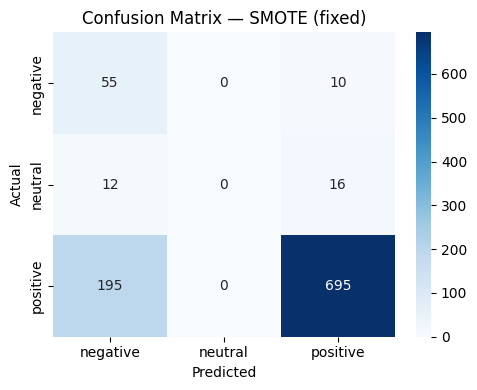

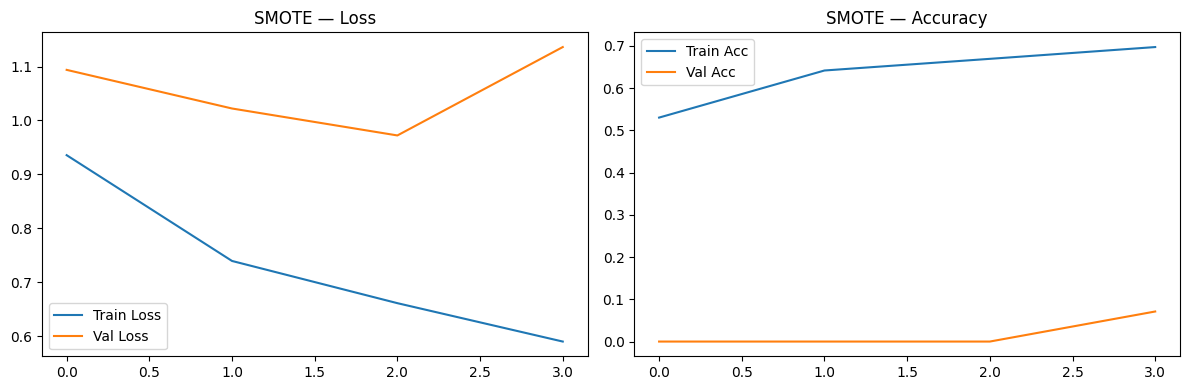

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ── Critical fix: SMOTE outputs floats; token IDs must be whole integers ──
# Round to nearest integer and clip to valid vocabulary range [0, MAX_WORDS-1]
X_train_smote = np.clip(np.round(X_train_smote).astype(int), 0, MAX_WORDS - 1)
print("After SMOTE (fixed):", np.bincount(y_train_smote))
print(f"Token ID range: [{X_train_smote.min()}, {X_train_smote.max()}]  ✓ valid")

model_smote = build_bilstm()

history_smote = model_smote.fit(
    X_train_smote, y_train_smote,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

f1_smote = evaluate_model(model_smote, X_test, y_test, label="SMOTE (fixed)")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_smote.history["loss"], label="Train Loss")
plt.plot(history_smote.history["val_loss"], label="Val Loss")
plt.title("SMOTE — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_smote.history["accuracy"], label="Train Acc")
plt.plot(history_smote.history["val_accuracy"], label="Val Acc")
plt.title("SMOTE — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── EXPERIMENT 6: Balanced Bagging Ensemble with Undersampling ─────
> Train **N independent BiLSTM models**, each on a **different random undersample** of the majority. Soft-vote (average probabilities) at inference.
> ⚠️ **Previous problem**: same aggressive full-balance strategy — each subset was tiny, so models trained on essentially nothing.
> **Fixes applied**:
> - `sampling_strategy='not majority'` keeps far more samples per estimator
> - Increased to **5 estimators** — more diversity, better coverage of the majority class across the ensemble

In [32]:
N_ESTIMATORS = 5   # more estimators → better coverage of the majority class

ensemble_models    = []
ensemble_histories = []

for i in range(N_ESTIMATORS):
    print(f"\n{'─'*50}")
    print(f"  Training estimator {i+1}/{N_ESTIMATORS}")
    print(f"{'─'*50}")

    # 'not majority' + different seeds → diverse subsets, adequate training size
    rus_i = RandomUnderSampler(random_state=i * 7, sampling_strategy='not majority')
    X_i, y_i = rus_i.fit_resample(X_train, y_train)
    print(f"  Subset: {np.bincount(y_i)}  (total={len(y_i)})")

    m = build_bilstm()
    h = m.fit(
        X_i, y_i,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=0
    )
    ensemble_models.append(m)
    ensemble_histories.append(h)
    best_val = max(h.history["val_accuracy"])
    print(f"  Estimator {i+1} done — best val_acc: {best_val:.4f}")

# ── Soft Voting ───────────────────────────────────────────────────
proba_list = [m.predict(X_test, verbose=0) for m in ensemble_models]
avg_proba  = np.mean(proba_list, axis=0)
y_pred_ens = np.argmax(avg_proba, axis=1)

from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(f"\n{'='*55}")
print(f"  Balanced Bagging Ensemble (Undersampling × {N_ESTIMATORS})")
print(f"{'='*55}")
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

cm_ens = confusion_matrix(y_test, y_pred_ens)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — Ensemble Undersampling ×{N_ESTIMATORS}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

f1_ensemble = f1_score(y_test, y_pred_ens, average="macro")
print(f"Macro-F1: {f1_ensemble:.4f}")


──────────────────────────────────────────────────
  Training estimator 1/5
──────────────────────────────────────────────────
  Subset: [ 114  114 3558]  (total=3786)


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


KeyboardInterrupt: 

# ── EXPERIMENT 7: Strong BiLSTM + Amplified Class Weights ─────────
> **Purpose-built for extreme class imbalance like Amazon reviews.**
> This model combines every improvement in one place:
> - **Deeper architecture**: Embedding → SpatialDropout → BiLSTM(128) → SpatialDropout → BiLSTM(64) → GlobalMaxPooling1D → Dense(128) → BN → Dense(64) → Softmax
> - **Aggressively amplified class weights** (power 1.5, normalised) — pushes hard on neutral (rarest) and negative
> - **ReduceLROnPlateau**: halves LR when validation loss stalls — lets the model refine minority boundaries
> - **30 epochs / patience=5** — enough time for minority classes to get meaningful gradient updates

Strong amplified class weights:
    negative: 0.6751
     neutral: 2.3117
    positive: 0.0133


d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_16            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_17            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_8          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.1510 - loss: 0.1283 - val_accuracy: 0.0381 - val_loss: 1.1595 - learning_rate: 3.0000e-04
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1128 - loss: 0.1309 - val_accuracy: 0.0381 - val_loss: 1.1988 - learning_rate: 3.0000e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1119 - loss: 0.1189
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
56/56 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.1032 - loss: 0.1158 - val_accuracy: 0.0381 - val_loss: 1.2491 - learning_rate: 3.0000e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.0882 - loss: 0.1194 - val_accuracy: 0.0381 - val_loss: 1.2644 - learning_rate: 1.5000e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1049 - loss: 0.1088
Epoch 5: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
56/56 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.1012 - loss: 0.1138 - va

d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


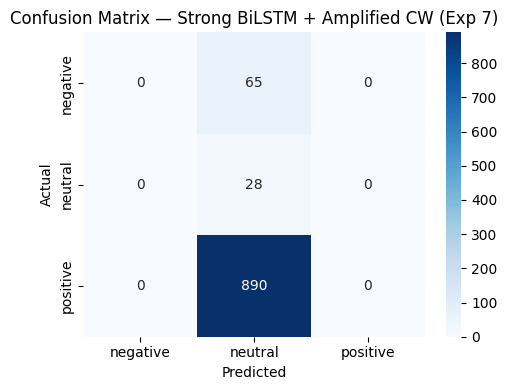

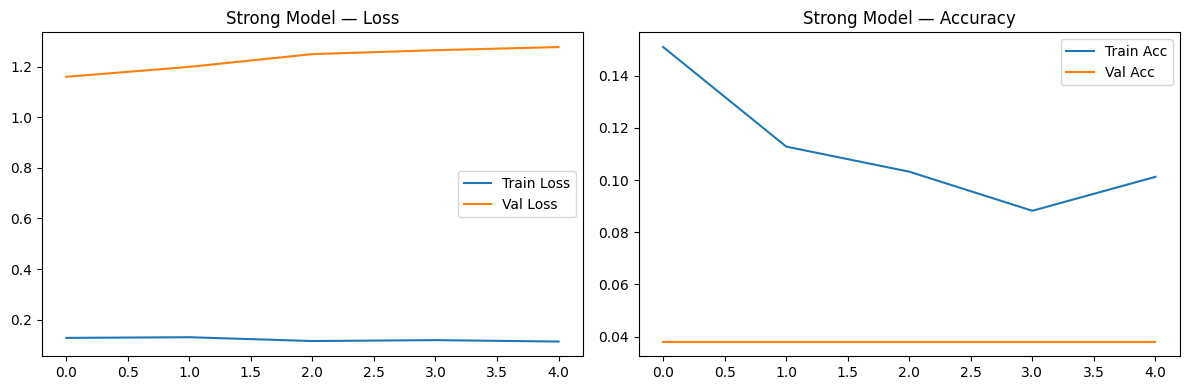

In [34]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ── Aggressively amplified class weights ─────────────────────────────────────
# Power 1.5 pushes harder on minority than the 1.3 used in Exp 2
cw_base = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_strong = cw_base ** 1.5
cw_strong = cw_strong / cw_strong.mean()   # normalise to keep loss scale stable
class_weights_strong = dict(enumerate(cw_strong))
print("Strong amplified class weights:")
for k, v in class_weights_strong.items():
    print(f"  {le.classes_[k]:>10s}: {v:.4f}")

# ── Architecture ─────────────────────────────────────────────────────────────
def build_strong_bilstm():
    """
    Deep BiLSTM with GlobalMaxPooling:
    - SpatialDropout1D regularises at the embedding level (drops feature maps, not tokens)
    - recurrent_dropout in LSTM regularises the hidden state transitions
    - GlobalMaxPooling1D picks the strongest per-feature signal across ALL time steps
      → very effective for sentiment: latches onto the most emotional word/phrase
    - BatchNorm + deeper Dense head stabilises training with amplified loss
    """
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.4),
        Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.15)),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.1)),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=3e-4),   # lower LR → finer minority-class updates
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_strong = build_strong_bilstm()
model_strong.summary()

# ── Callbacks ────────────────────────────────────────────────────────────────
es_strong  = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True,
                            verbose=1)
rlr_strong = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                                min_lr=1e-6, verbose=1)

history_strong = model_strong.fit(
    X_train, y_train,
    epochs=5,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weights_strong,
    callbacks=[es_strong, rlr_strong],
    verbose=1
)

f1_strong = evaluate_model(model_strong, X_test, y_test,
                            label="Strong BiLSTM + Amplified CW (Exp 7)")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_strong.history["loss"], label="Train Loss")
plt.plot(history_strong.history["val_loss"], label="Val Loss")
plt.title("Strong Model — Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_strong.history["accuracy"], label="Train Acc")
plt.plot(history_strong.history["val_accuracy"], label="Val Acc")
plt.title("Strong Model — Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

# ── FINAL COMPARISON — All 7 Experiments ──────────────────────────
> **Macro-F1** is the ranking metric — it gives equal weight to all 3 classes (negative, neutral, positive). A model that ignores neutral and negative would score high on accuracy but very low on macro-F1.
> The final cell also prints the full per-class precision/recall/F1 for the winning method, so we can see exactly how well it learned each of the 3 sentiments.

⚠️  Skipped (not run): ['Ensemble Undersampling']
                      Method  Macro-F1
                    Baseline  0.511098
                Oversampling  0.507776
                       SMOTE  0.399737
               Undersampling  0.316782
   Class Weights (Amplified)  0.064273
Strong BiLSTM + Amplified CW  0.018464


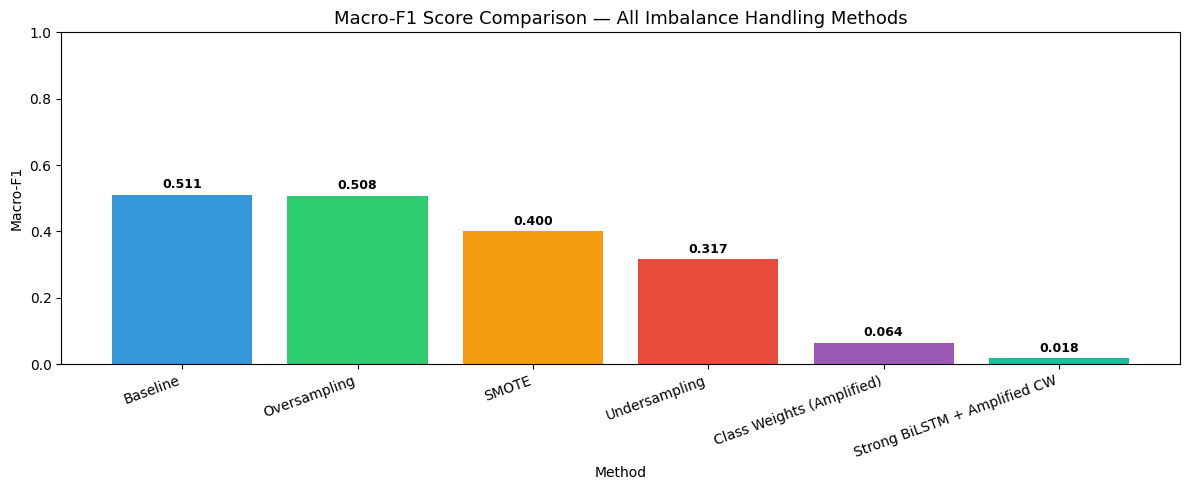


✅ Best method: Baseline  (Macro-F1 = 0.5111)

Detailed per-class report for the best model:
              precision    recall  f1-score   support

    negative       0.60      0.54      0.57        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.98      0.96       890

    accuracy                           0.93       983
   macro avg       0.52      0.51      0.51       983
weighted avg       0.90      0.93      0.91       983



d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJECTS\bct-genai\product_review_sentiment_analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [40]:
import pandas as pd
import numpy as np

# ── Collect scores — use None for any experiment that wasn't run ──────────────
all_experiments = {
    "Baseline":                     globals().get("f1_baseline"),
    "Class Weights (Amplified)":    globals().get("f1_cw"),
    "Oversampling":                 globals().get("f1_ros"),
    "Undersampling":                globals().get("f1_rus"),
    "SMOTE":                        globals().get("f1_smote"),
    "Ensemble Undersampling":       globals().get("f1_ensemble"),
    "Strong BiLSTM + Amplified CW": globals().get("f1_strong"),
}

# Drop any experiments that were not executed
available = {k: v for k, v in all_experiments.items() if v is not None}
if len(available) < len(all_experiments):
    skipped = [k for k, v in all_experiments.items() if v is None]
    print(f"⚠️  Skipped (not run): {skipped}")

results = pd.DataFrame({
    "Method":   list(available.keys()),
    "Macro-F1": list(available.values())
}).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
all_colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6", "#1abc9c", "#e67e22"]
palette = all_colors[:len(results)]

plt.figure(figsize=(12, 5))
bars = plt.bar(results["Method"], results["Macro-F1"], color=palette)
plt.ylim(0, 1)
plt.title("Macro-F1 Score Comparison — All Imbalance Handling Methods", fontsize=13)
plt.ylabel("Macro-F1")
plt.xlabel("Method")
plt.xticks(rotation=20, ha="right")
for bar, val in zip(bars, results["Macro-F1"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.show()

# ── Per-class breakdown for the best model ────────────────────────────────────
from sklearn.metrics import classification_report

best_method = results.iloc[0]["Method"]
best_model_map = {
    "Baseline":                      globals().get("model_baseline"),
    "Class Weights (Amplified)":     globals().get("model_cw"),
    "Oversampling":                  globals().get("model_ros"),
    "Undersampling":                 globals().get("model_rus"),
    "SMOTE":                         globals().get("model_smote"),
    "Ensemble Undersampling":        None,   # uses avg_proba directly
    "Strong BiLSTM + Amplified CW":  globals().get("model_strong"),
}

print(f"\n✅ Best method: {best_method}  (Macro-F1 = {results.iloc[0]['Macro-F1']:.4f})")
best_model = best_model_map.get(best_method)
if best_model is not None:
    y_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
elif best_method == "Ensemble Undersampling" and globals().get("y_pred_ens") is not None:
    y_best = y_pred_ens
else:
    print("Best model not available for detailed report.")
    y_best = None

if y_best is not None:
    print("\nDetailed per-class report for the best model:")
    print(classification_report(y_test, y_best, target_names=le.classes_))